# Конструкция алгоритма генерации квадратных графов

Функция генерации графа в виде прямоугольной сетки с шагом.

In [ ]:
import osmnx as ox
from osmnx import utils
import networkx as nx
import numpy as np
import pandas as pd

In [ ]:
def generate_grid_graph(n: int, 
                        m: int, 
                        step: float = 100.0,
                        speed: float = 50.0,
                        crs = 'EPSG:3857',
                        add_geometry: bool = True) -> nx.MultiDiGraph:
    '''
    Генерация графа улично-дорожной сети в виде прямоугольной сетки.
    
    Аргументы:
        `n`: int
            Количество узлов по оси X (ширина сетки)
        
        `m`: int
            Количество узлов по оси Y (высота сетки)
        
        `step`: float = 100.0
            Расстояние между соседними узлами (в метрах)
        
        `speed`: float = 50.0
            Скорость движения по ребрам (км/ч) для расчета времени в пути

        `crs`: str = 'EPSG:3857
            Система координат
        
        `add_geometry`: bool = True
            Добавлять ли геометрию (LineString) к ребрам
    
    Возвращает:
        `G`: nx.MultiDiGraph
            Направленный мультиграф с узлами и ребрами в виде сетки
    '''
    from shapely.geometry import Point, LineString
    
    # Создание пустого мультиграфа
    metadata = {
            "created_date": utils.ts(),
            "created_with": f"OSMnx {ox.__version__}",
            "crs": crs
        }
    G = nx.MultiDiGraph(**metadata)

    
    # Генерация узлов
    node_id = 0
    node_positions = {}  # Для хранения соответствия (i, j) -> node_id
    
    for i in range(n):
        for j in range(m):
            # Координаты узла
            x = i * step
            y = j * step
            
            # Добавление узла с атрибутами
            G.add_node(node_id, 
                      x=x, 
                      y=y,
                      # pos=(x, y),
                      geometry=Point(x, y) if add_geometry else None)
            
            node_positions[(i, j)] = node_id
            node_id += 1
    
    # Генерация ребер между соседними узлами
    for i in range(n):
        for j in range(m):
            current_node = node_positions[(i, j)]
            
            # Соединяем с правым соседом (i+1, j)
            if i + 1 < n:
                right_node = node_positions[(i + 1, j)]
                add_edge_with_attributes(G, current_node, right_node, step, speed, add_geometry)
                add_edge_with_attributes(G, right_node, current_node, step, speed, add_geometry)
            
            # Соединяем с верхним соседом (i, j+1)
            if j + 1 < m:
                top_node = node_positions[(i, j + 1)]
                add_edge_with_attributes(G, current_node, top_node, step, speed, add_geometry)
                add_edge_with_attributes(G, top_node, current_node, step, speed, add_geometry)
    
    return G


def add_edge_with_attributes(G, u, v, length, speed, add_geometry=True):
    '''
    Добавляет ребро с необходимыми атрибутами.
    
    Аргументы:
        `G`: nx.MultiDiGraph
            Граф
        `u`, `v`: int
            Узлы начала и конца ребра
        `length`: float
            Длина ребра (в метрах)
        `speed`: float
            Скорость движения (км/ч)
        `add_geometry`: bool
            Добавлять ли геометрию LineString
    '''
    from shapely.geometry import LineString
    
    # Расчет времени в пути (в секундах)
    # length в метрах, speed в км/ч
    travel_time = (length / 1000.0) / speed * 3600.0  # секунды
    
    # Атрибуты ребра
    edge_attrs = {
        'length': length,
        'travel_time': travel_time,
        'speed_kph': speed,
    }
    
    # Добавление геометрии если требуется
    if add_geometry:
        u_data = G.nodes[u]
        v_data = G.nodes[v]
        edge_attrs['geometry'] = LineString([
            (u_data['x'], u_data['y']),
            (v_data['x'], v_data['y'])
        ])
    
    G.add_edge(u, v, **edge_attrs)


def remove_random_elements(G, 
                          remove_nodes: int = 0, 
                          remove_edges: int = 0,
                          copy: bool = True) -> nx.MultiDiGraph:
    '''
    Случайное удаление узлов или ребер из графа.
    
    Аргументы:
        `G`: nx.MultiDiGraph
            Исходный граф
        
        `remove_nodes`: int = 0
            Количество узлов для удаления
        
        `remove_edges`: int = 0
            Количество ребер для удаления
        
        `copy`: bool = True
            Создавать копию графа (True) или изменять исходный (False)
    
    Возвращает:
        `G_modified`: nx.MultiDiGraph
            Граф с удаленными элементами
    '''
    import random
    
    if copy:
        G = G.copy()
    
    # Удаление случайных узлов
    if remove_nodes > 0:
        nodes_list = list(G.nodes())
        nodes_to_remove = random.sample(nodes_list, min(remove_nodes, len(nodes_list)))
        G.remove_nodes_from(nodes_to_remove)
    
    # Удаление случайных ребер
    if remove_edges > 0:
        edges_list = list(G.edges(keys=True))
        edges_to_remove = random.sample(edges_list, min(remove_edges, len(edges_list)))
        for u, v, k in edges_to_remove:
            G.remove_edge(u, v, k)
    
    return G

In [ ]:
# Пример: удаление случайных элементов
G_original = generate_grid_graph(n=10, m=10, step=100.0)
print(f"Исходный граф: {G_original.number_of_nodes()} узлов, {G_original.number_of_edges()} ребер")

# Удаление 20 узлов
G_nodes = remove_random_elements(G_original, remove_nodes=20)
print(f"После удаления 20 узлов: {G_nodes.number_of_nodes()} узлов, {G_nodes.number_of_edges()} ребер")

# Удаление 50 ребер
G_edges = remove_random_elements(G_original, remove_edges=50)
print(f"После удаления 50 ребер: {G_edges.number_of_nodes()} узлов, {G_edges.number_of_edges()} ребер")

# Удаление и узлов, и ребер
G_both = remove_random_elements(G_original, remove_nodes=10, remove_edges=30)
print(f"После удаления 10 узлов и 30 ребер: {G_both.number_of_nodes()} узлов, {G_both.number_of_edges()} ребер")


Исходный граф: 100 узлов, 360 ребер
После удаления 20 узлов: 80 узлов, 232 ребер
После удаления 50 ребер: 100 узлов, 310 ребер
После удаления 10 узлов и 30 ребер: 90 узлов, 264 ребер


## Пример 1: Простая сетка 5×5

In [ ]:
# Генерация графа 5x5 с шагом 100 метров
G = generate_grid_graph(n=5, m=5, step=100.0, speed=50.0)

# Информация о графе
print(f"Узлов: {G.number_of_nodes()}")
print(f"Ребер: {G.number_of_edges()}")
print(f"\nПример узла 0: {G.nodes[0]}")
print(f"\nПример ребра (0, 1): {G.edges[0, 1, 0]}")


Узлов: 25
Ребер: 80

Пример узла 0: {'x': 0.0, 'y': 0.0, 'geometry': <POINT (0 0)>}

Пример ребра (0, 1): {'length': 100.0, 'travel_time': 7.2, 'speed_kph': 50.0, 'geometry': <LINESTRING (0 0, 0 100)>}


## Пример 2: Визуализация графа


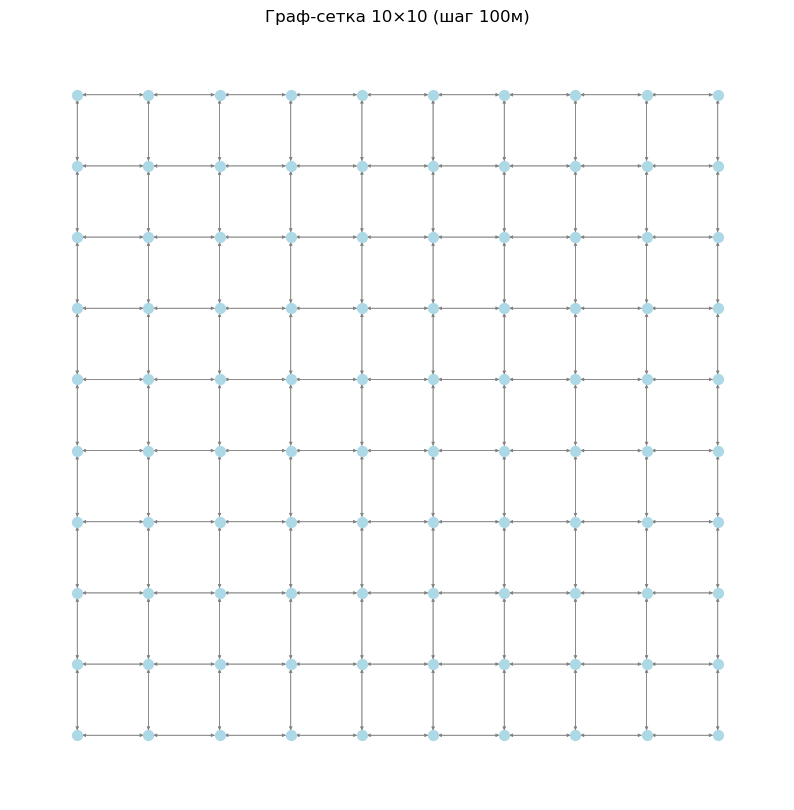

In [ ]:
import matplotlib.pyplot as plt

# Генерация графа 10x10
G = generate_grid_graph(n=10, m=10, step=100.0)

# Получение позиций узлов для визуализации
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# Визуализация
fig, ax = plt.subplots(figsize=(10, 10))
nx.draw(G, pos, 
        node_size=50, 
        node_color='lightblue',
        edge_color='gray',
        width=0.5,
        arrows=True,
        arrowsize=5,
        ax=ax)

ax.set_title('Граф-сетка 10×10 (шаг 100м)')
ax.set_xlabel('X (метры)')
ax.set_ylabel('Y (метры)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()


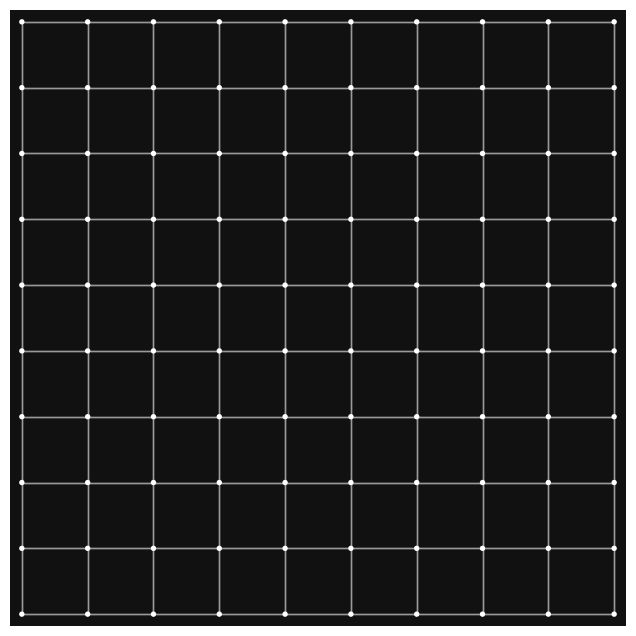

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph(G)

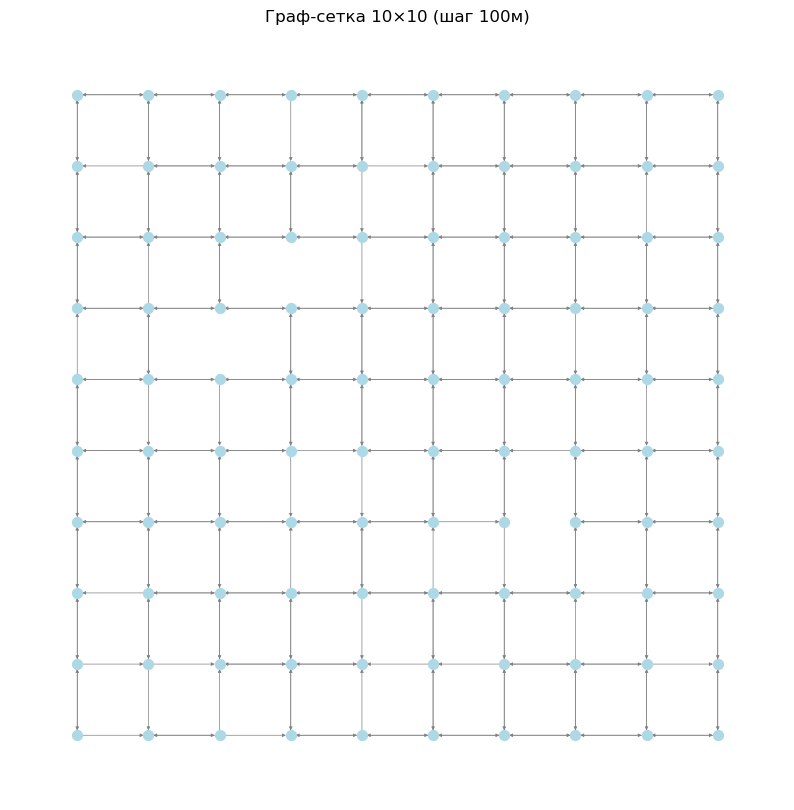

In [ ]:
G_hard = remove_random_elements(G, remove_edges=40)
# ox.plot_graph(G_hard)
# Получение позиций узлов для визуализации
pos = {node: (data['x'], data['y']) for node, data in G_hard.nodes(data=True)}

# Визуализация
fig, ax = plt.subplots(figsize=(10, 10))
nx.draw(G_hard, pos, 
        node_size=50, 
        node_color='lightblue',
        edge_color='gray',
        width=0.5,
        arrows=True,
        arrowsize=5,
        ax=ax)

ax.set_title('Граф-сетка 10×10 (шаг 100м)')
ax.set_xlabel('X (метры)')
ax.set_ylabel('Y (метры)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

## Пример 3: Работа с osmnx (конвертация в GeoDataFrame)


In [ ]:
# Генерация графа
G = generate_grid_graph(n=8, m=8, step=150.0, speed=60.0)

# Конвертация в GeoDataFrame используя osmnx
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

print("Узлы (GeoDataFrame):")
print(nodes_gdf.head())
print("\nРебра (GeoDataFrame):")
print(edges_gdf.head())


Узлы (GeoDataFrame):
         x      y       geometry
osmid                           
0      0.0    0.0    POINT (0 0)
1      0.0  150.0  POINT (0 150)
2      0.0  300.0  POINT (0 300)
3      0.0  450.0  POINT (0 450)
4      0.0  600.0  POINT (0 600)

Ребра (GeoDataFrame):
         length  travel_time  speed_kph                     geometry
u v key                                                             
0 8 0     150.0          9.0       60.0      LINESTRING (0 0, 150 0)
  1 0     150.0          9.0       60.0      LINESTRING (0 0, 0 150)
1 0 0     150.0          9.0       60.0      LINESTRING (0 150, 0 0)
  9 0     150.0          9.0       60.0  LINESTRING (0 150, 150 150)
  2 0     150.0          9.0       60.0    LINESTRING (0 150, 0 300)


## Пример 4: Расчет кратчайших путей


In [ ]:
# Генерация графа 15x15
G = generate_grid_graph(n=15, m=15, step=100.0, speed=50.0)

# Расчет кратчайшего пути от узла 0 до узла 224 (противоположный угол)
source_node = 0
target_node = 200

# Кратчайший путь по времени
shortest_path = nx.shortest_path(G, source=source_node, target=target_node, weight='travel_time')
path_length = nx.shortest_path_length(G, source=source_node, target=target_node, weight='travel_time')

print(f"Кратчайший путь от узла {source_node} до узла {target_node}:")
print(f"Количество узлов в пути: {len(shortest_path)}")
print(f"Время в пути: {path_length:.2f} секунд ({path_length/60:.2f} минут)")
print(f"Первые 10 узлов пути: {shortest_path[:10]}")


Кратчайший путь от узла 0 до узла 200:
Количество узлов в пути: 19
Время в пути: 129.60 секунд (2.16 минут)
Первые 10 узлов пути: [0, 15, 30, 45, 60, 75, 90, 105, 120, 135]


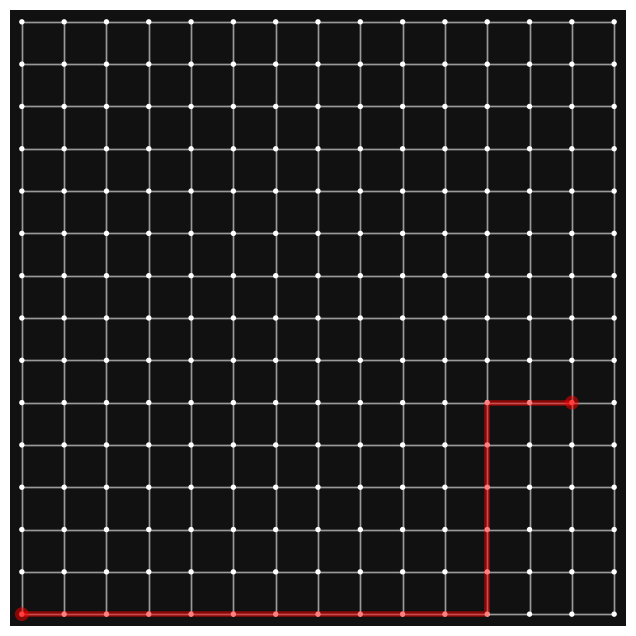

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
route = ox.shortest_path(G, source_node, target_node, weight='travel_time')
ox.plot_graph_route(G, route)

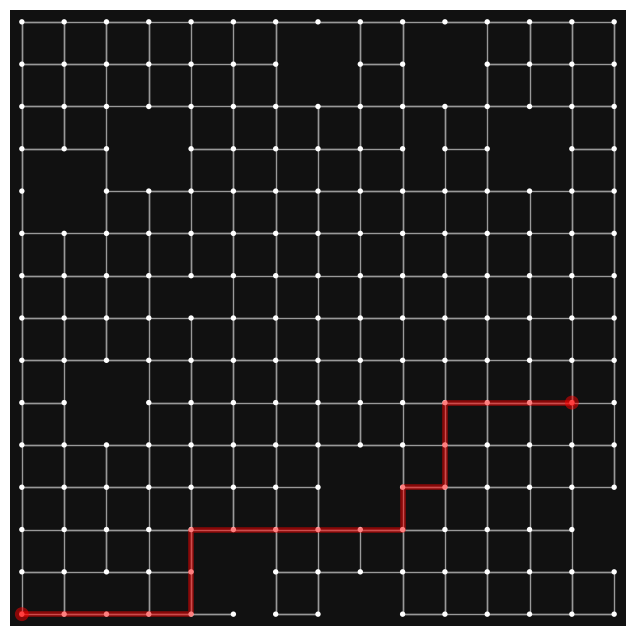

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
G_hard = remove_random_elements(G, remove_nodes=10, remove_edges=100)

route = ox.shortest_path(G_hard, source_node, target_node, weight='travel_time')
ox.plot_graph_route(G_hard, route)

## Пример 5: Различные размеры и параметры


In [ ]:
# Прямоугольная сетка 20x10 с шагом 200 метров и скоростью 80 км/ч
G_rect = generate_grid_graph(n=20, m=10, step=200.0, speed=80.0)

print(f"Прямоугольная сетка 20×10:")
print(f"  Узлов: {G_rect.number_of_nodes()}")
print(f"  Ребер: {G_rect.number_of_edges()}")

# Большая квадратная сетка 50x50
G_large = generate_grid_graph(n=50, m=50, step=50.0, speed=40.0)

print(f"\nБольшая сетка 50×50:")
print(f"  Узлов: {G_large.number_of_nodes()}")
print(f"  Ребер: {G_large.number_of_edges()}")


Прямоугольная сетка 20×10:
  Узлов: 200
  Ребер: 740

Большая сетка 50×50:
  Узлов: 2500
  Ребер: 9800


## Пример 6: Визуализация кратчайшего пути


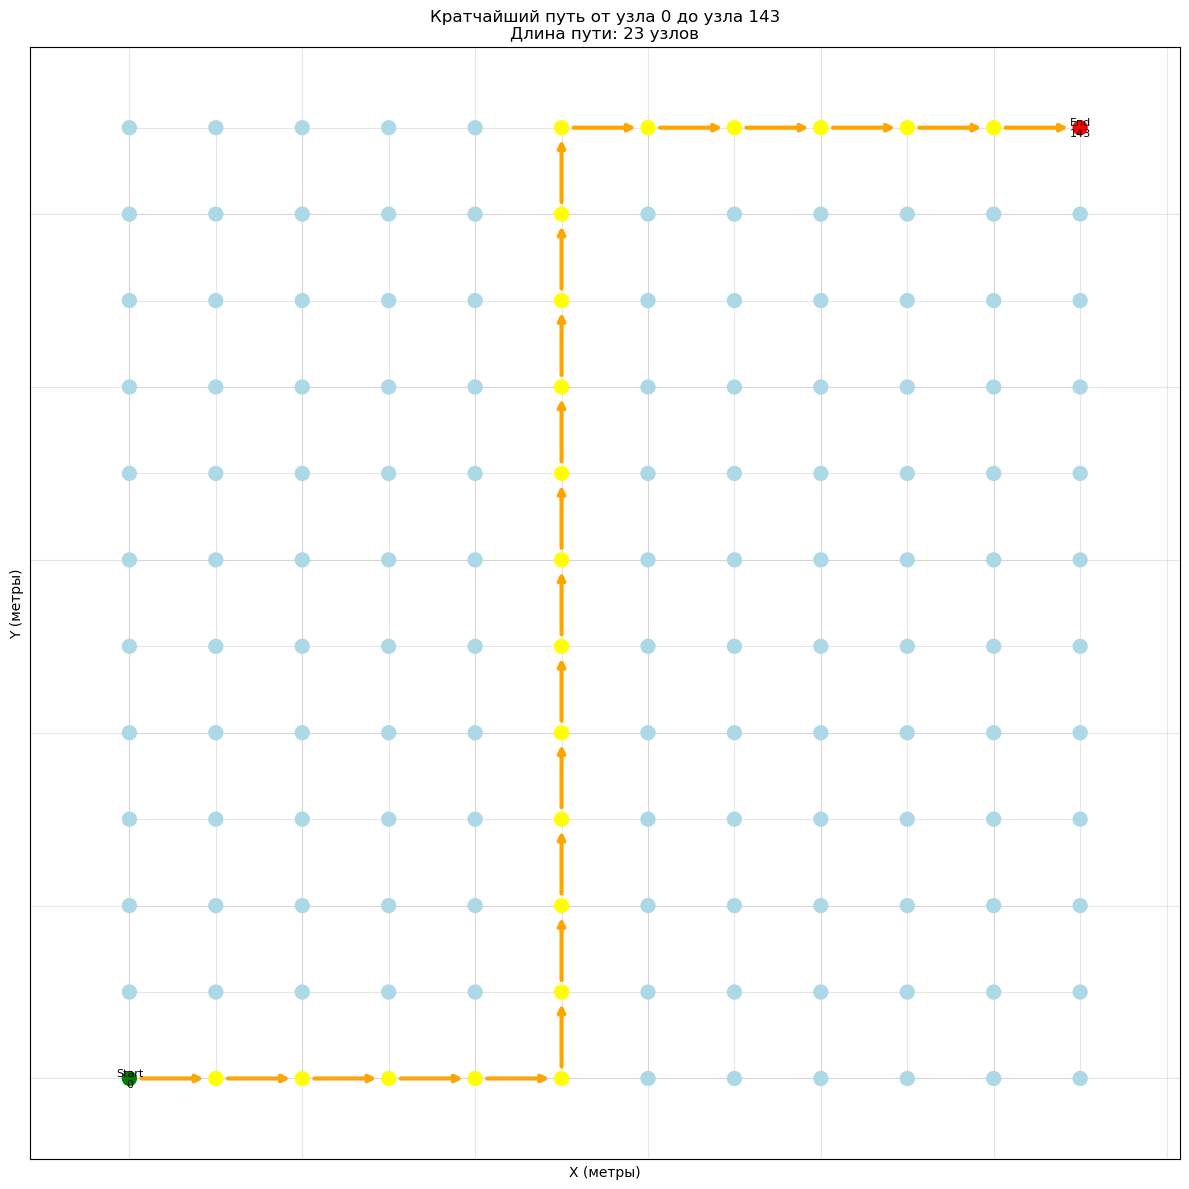

In [ ]:
# Генерация графа 12x12
G = generate_grid_graph(n=12, m=12, step=100.0, speed=50.0)

# Расчет кратчайшего пути
source = 0  # Нижний левый угол
target = 143  # Верхний правый угол
path = nx.shortest_path(G, source=source, target=target, weight='travel_time')

# Подготовка данных для визуализации
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# Цвета узлов
node_colors = []
for node in G.nodes():
    if node == source:
        node_colors.append('green')  # Начало
    elif node == target:
        node_colors.append('red')    # Конец
    elif node in path:
        node_colors.append('yellow') # Путь
    else:
        node_colors.append('lightblue')

# Визуализация
fig, ax = plt.subplots(figsize=(12, 12))

# Рисуем все ребра
nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=0.5, 
                       arrows=False, alpha=0.5, ax=ax)

# Рисуем путь
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, 
                       edge_color='orange', width=3, 
                       arrows=True, arrowsize=10, ax=ax)

# Рисуем узлы
nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                       node_size=100, ax=ax)

# Подписываем начальный и конечный узлы
nx.draw_networkx_labels(G, pos, labels={source: f'Start\n{source}', 
                                        target: f'End\n{target}'}, 
                        font_size=8, ax=ax)

ax.set_title(f'Кратчайший путь от узла {source} до узла {target}\nДлина пути: {len(path)} узлов')
ax.set_xlabel('X (метры)')
ax.set_ylabel('Y (метры)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Дополнительная информация

### Особенности функции:

1. **Структура графа**: Создается направленный мультиграф (`nx.MultiDiGraph`), где каждая пара соседних узлов соединена ребрами в обоих направлениях.

2. **Атрибуты узлов**:
   - `x`, `y` — координаты узла в метрах
   - `pos` — кортеж координат (x, y)
   - `geometry` — объект Point из Shapely (если `add_geometry=True`)

3. **Атрибуты ребер**:
   - `length` — длина ребра в метрах
   - `travel_time` — время прохождения в секундах
   - `speed_kph` — скорость движения в км/ч
   - `geometry` — объект LineString из Shapely (если `add_geometry=True`)

4. **Нумерация узлов**: Узлы нумеруются построчно слева направо, снизу вверх:
   ```
   5  6  7  8  9
   0  1  2  3  4
   ```

### Применение:

- Тестирование алгоритмов поиска путей
- Генерация синтетических данных для задач размещения
- Проверка производительности алгоритмов на графах различного размера
- Обучение и демонстрация работы с графами NetworkX

### Производительность:

- Сетка 10×10: ~100 узлов, ~360 ребер
- Сетка 50×50: ~2,500 узлов, ~9,800 ребер
- Сетка 100×100: ~10,000 узлов, ~39,600 ребер


## Расширенная версия с диагональными связями


In [ ]:
def generate_grid_graph_extended(n: int, 
                                 m: int, 
                                 step: float = 100.0,
                                 speed: float = 50.0,
                                 crs = 'EPSG:3857',
                                 add_geometry: bool = True,
                                 diagonals: bool = False) -> nx.MultiDiGraph:
    '''
    Генерация графа улично-дорожной сети в виде прямоугольной сетки с опцией диагональных связей.
    
    Аргументы:
        `n`: int
            Количество узлов по оси X (ширина сетки)
        
        `m`: int
            Количество узлов по оси Y (высота сетки)
        
        `step`: float = 100.0
            Расстояние между соседними узлами (в метрах)
        
        `speed`: float = 50.0
            Скорость движения по ребрам (км/ч) для расчета времени в пути
        
        `crs`: str = 'EPSG:3857
            Система координат
        
        `add_geometry`: bool = True
            Добавлять ли геометрию (LineString) к ребрам
        
        `diagonals`: bool = False
            Добавлять ли диагональные связи между узлами
    
    Возвращает:
        `G`: nx.MultiDiGraph
            Направленный мультиграф с узлами и ребрами в виде сетки
    '''
    from shapely.geometry import Point, LineString
    import math
    
    # Создание пустого мультиграфа
    metadata = {
            "created_date": utils.ts(),
            "created_with": f"OSMnx {ox.__version__}",
            "crs": crs
        }
    G = nx.MultiDiGraph(**metadata)
    
    # Генерация узлов
    node_id = 0
    node_positions = {}  # Для хранения соответствия (i, j) -> node_id
    
    for i in range(n):
        for j in range(m):
            # Координаты узла
            x = i * step
            y = j * step
            
            # Добавление узла с атрибутами
            G.add_node(node_id, 
                      x=x, 
                      y=y,
                      pos=(x, y),
                      geometry=Point(x, y) if add_geometry else None)
            
            node_positions[(i, j)] = node_id
            node_id += 1
    
    # Генерация ребер между соседними узлами
    for i in range(n):
        for j in range(m):
            current_node = node_positions[(i, j)]
            
            # Горизонтальные и вертикальные связи
            # Соединяем с правым соседом (i+1, j)
            if i + 1 < n:
                right_node = node_positions[(i + 1, j)]
                add_edge_with_attributes(G, current_node, right_node, step, speed, add_geometry)
                add_edge_with_attributes(G, right_node, current_node, step, speed, add_geometry)
            
            # Соединяем с верхним соседом (i, j+1)
            if j + 1 < m:
                top_node = node_positions[(i, j + 1)]
                add_edge_with_attributes(G, current_node, top_node, step, speed, add_geometry)
                add_edge_with_attributes(G, top_node, current_node, step, speed, add_geometry)
            
            # Диагональные связи
            if diagonals:
                diagonal_length = step * math.sqrt(2)
                
                # Диагональ вправо-вверх (i+1, j+1)
                if i + 1 < n and j + 1 < m:
                    diag_node = node_positions[(i + 1, j + 1)]
                    add_edge_with_attributes(G, current_node, diag_node, diagonal_length, speed, add_geometry)
                    add_edge_with_attributes(G, diag_node, current_node, diagonal_length, speed, add_geometry)
                
                # Диагональ влево-вверх (i-1, j+1)
                if i - 1 >= 0 and j + 1 < m:
                    diag_node = node_positions[(i - 1, j + 1)]
                    add_edge_with_attributes(G, current_node, diag_node, diagonal_length, speed, add_geometry)
                    add_edge_with_attributes(G, diag_node, current_node, diagonal_length, speed, add_geometry)
    
    return G


## Пример 7: Сравнение графов с диагоналями и без


In [ ]:
# Генерация двух графов 8x8
G_no_diag = generate_grid_graph_extended(n=8, m=8, step=100.0, diagonals=False)
G_with_diag = generate_grid_graph_extended(n=8, m=8, step=100.0, diagonals=True)

print("Граф без диагоналей:")
print(f"  Узлов: {G_no_diag.number_of_nodes()}")
print(f"  Ребер: {G_no_diag.number_of_edges()}")

print("\nГраф с диагоналями:")
print(f"  Узлов: {G_with_diag.number_of_nodes()}")
print(f"  Ребер: {G_with_diag.number_of_edges()}")

# Сравнение кратчайших путей
source = 0
target = 63

path_no_diag = nx.shortest_path(G_no_diag, source=source, target=target, weight='length')
length_no_diag = nx.shortest_path_length(G_no_diag, source=source, target=target, weight='length')

path_with_diag = nx.shortest_path(G_with_diag, source=source, target=target, weight='length')
length_with_diag = nx.shortest_path_length(G_with_diag, source=source, target=target, weight='length')

print(f"\nКратчайший путь от {source} до {target}:")
print(f"  Без диагоналей: {len(path_no_diag)} узлов, {length_no_diag:.2f} метров")
print(f"  С диагоналями:  {len(path_with_diag)} узлов, {length_with_diag:.2f} метров")
print(f"  Выигрыш в расстоянии: {(length_no_diag - length_with_diag):.2f} метров ({100*(length_no_diag - length_with_diag)/length_no_diag:.1f}%)")


Граф без диагоналей:
  Узлов: 64
  Ребер: 224

Граф с диагоналями:
  Узлов: 64
  Ребер: 420

Кратчайший путь от 0 до 63:
  Без диагоналей: 15 узлов, 1400.00 метров
  С диагоналями:  8 узлов, 989.95 метров
  Выигрыш в расстоянии: 410.05 метров (29.3%)


## Пример 8: Визуализация графа с диагоналями


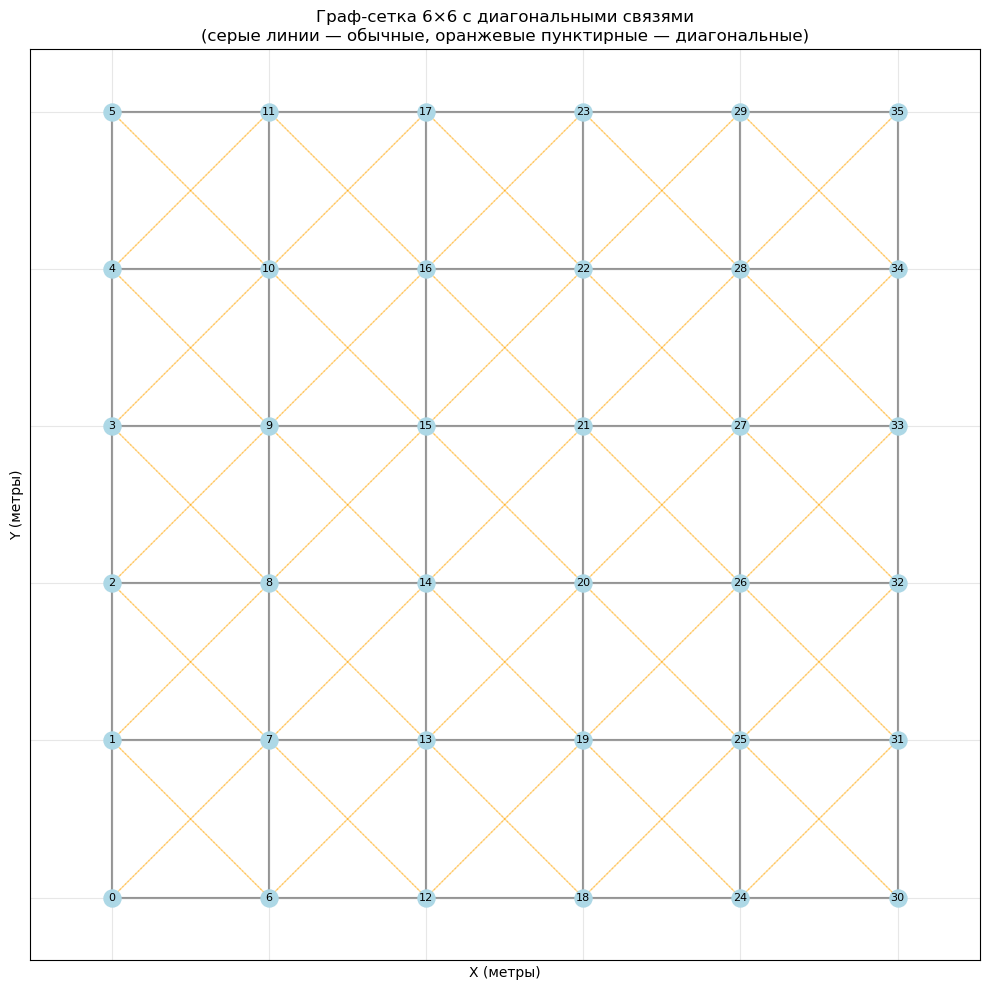

In [ ]:
# Генерация графа с диагоналями
G = generate_grid_graph_extended(n=6, m=6, step=100.0, diagonals=True)

# Получение позиций узлов для визуализации
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# Визуализация
fig, ax = plt.subplots(figsize=(10, 10))

# Разделение ребер на обычные и диагональные для разного отображения
regular_edges = []
diagonal_edges = []

for u, v, data in G.edges(data=True):
    u_pos = pos[u]
    v_pos = pos[v]
    # Проверяем, является ли ребро диагональным по расстоянию
    if abs(data['length'] - 100.0) < 1:  # Обычное ребро
        regular_edges.append((u, v))
    else:  # Диагональное ребро
        diagonal_edges.append((u, v))

# Рисуем обычные ребра
nx.draw_networkx_edges(G, pos, edgelist=regular_edges,
                       edge_color='gray', width=1.5, 
                       arrows=False, alpha=0.6, ax=ax)

# Рисуем диагональные ребра
nx.draw_networkx_edges(G, pos, edgelist=diagonal_edges,
                       edge_color='orange', width=1.0, style='dashed',
                       arrows=False, alpha=0.4, ax=ax)

# Рисуем узлы
nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                       node_size=150, ax=ax)

# Добавляем подписи узлов
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

ax.set_title('Граф-сетка 6×6 с диагональными связями\n(серые линии — обычные, оранжевые пунктирные — диагональные)')
ax.set_xlabel('X (метры)')
ax.set_ylabel('Y (метры)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Пример 9: Интеграция с функциями genesis (расчет матрицы времен прибытия)


In [ ]:
import geopandas as gpd
from genesis.states import get_atm

# Генерация графа 20x20 для тестирования
# G_test = generate_grid_graph(n=20, m=100, step=100.0, speed=50.0)
G_test = generate_grid_graph_extended(n=100, m=100, step=100.0, diagonals=True)

print(f"Создан граф: {G_test.number_of_nodes()} узлов, {G_test.number_of_edges()} ребер")

# Получение GeoDataFrame узлов для использования в get_atm
nodes_gdf = ox.graph_to_gdfs(G_test, edges=False)
nodes_gdf['node'] = nodes_gdf.index

# Выборка для демонстрации (первые 50 узлов)
sample_nodes = nodes_gdf.sample(1000)

print(f"\\nРасчет матрицы времен прибытия для {len(sample_nodes)} узлов...")

# Расчет матрицы времен прибытия
matrix = get_atm(
    G=G_test,
    data=sample_nodes,
    data_node_field='node',
    weight='travel_time',
    cutoff=300.0,  # 5 минут
    delay=30.0,    # 30 секунд задержки
    print_calc_states=True
)

print(f"\\nРазмер матрицы: {matrix.shape}")
print(f"Покрытие: {matrix.notna().sum().sum()} значений из {matrix.size} возможных")
print(f"\\nПример матрицы (первые 5x5):")
print(matrix.iloc[:5, :5])


Создан граф: 10000 узлов, 78804 ребер
\nРасчет матрицы времен прибытия для 1000 узлов...
|########################################| 100.0%
\nРазмер матрицы: (1000, 10000)
Покрытие: 2834336 значений из 10000000 возможных
\nПример матрицы (первые 5x5):
            6828        6728        6827        6928        6829
6828   30.000000   37.200000   37.200000   37.200000   37.200000
7610  183.458701  186.441039  176.258701  180.476364  190.658701
8511  203.099740  210.299740  200.117402  200.117402  210.299740
7727   97.782338  104.982338   94.800000   90.582338  100.764675
4613  233.135065  225.935065  230.152727  240.335065  236.117402


In [ ]:
g_nodes = ox.graph_to_gdfs(G_test, edges=False)
g_nodes = g_nodes.merge(pd.Series(np.mean(matrix, axis=0), name='at_mean'),
                        left_index=True,
                        right_index=True)
g_nodes

,x,y,pos,geometry,at_mean
0,0.0,0.0,"(0.0, 0.0)",POINT (0 0),205.762950
1,0.0,100.0,"(0.0, 100.0)",POINT (0 100),205.055008
2,0.0,200.0,"(0.0, 200.0)",POINT (0 200),204.437151
3,0.0,300.0,"(0.0, 300.0)",POINT (0 300),205.010530
4,0.0,400.0,"(0.0, 400.0)",POINT (0 400),201.049652
...,...,...,...,...,...
9995,9900.0,9500.0,"(9900.0, 9500.0)",POINT (9900 9500),193.729834
9996,9900.0,9600.0,"(9900.0, 9600.0)",POINT (9900 9600),195.275660
9997,9900.0,9700.0,"(9900.0, 9700.0)",POINT (9900 9700),195.847327
9998,9900.0,9800.0,"(9900.0, 9800.0)",POINT (9900 9800),196.711476


<Axes: >

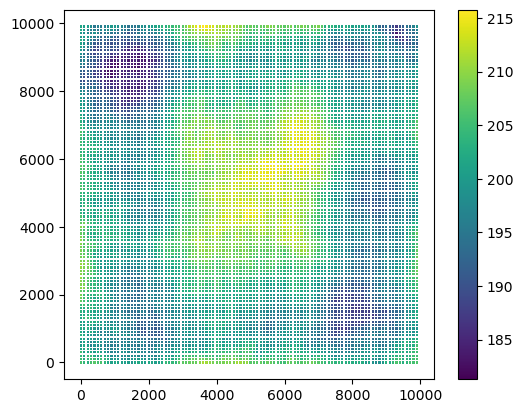

In [ ]:
g_nodes.plot(column='at_mean', legend=True, markersize=2.5, marker='s', edgecolor='none')

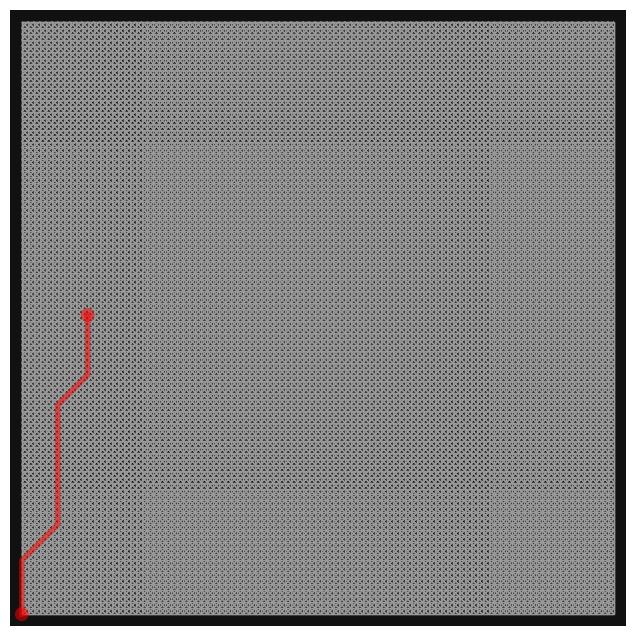

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
route = ox.shortest_path(G_test, orig=0, dest=1150, weight='travel_time')
ox.plot_graph_route(G_test, route, node_size=0)

## Рекомендации по производительности

### Оптимизация для больших графов:

1. **Без геометрии для больших сеток**: Если не требуется визуализация, установите `add_geometry=False` для экономии памяти.

2. **Выбор размера**: 
   - Малые графы (до 30×30): быстрые тесты
   - Средние графы (30×30 до 100×100): реалистичные тесты
   - Большие графы (100×100+): тесты производительности

3. **Диагональные связи**: Добавление диагоналей увеличивает количество ребер примерно в 2 раза, что замедляет алгоритмы поиска путей.

4. **Использование с get_atm**: Для больших сеток (50×50+) используйте параметр `data_sample_size` или `cutoff` для ограничения расчетов.


In [ ]:
# Тест производительности генерации графов различных размеров
import time

sizes = [(10, 10), (25, 25), (50, 50), (100, 100)]

print("Тест производительности генерации графов:\\n")
print(f"{'Размер':<15} {'Узлов':<10} {'Ребер':<10} {'Время (сек)':<15}")
print("-" * 50)

for n, m in sizes:
    start_time = time.time()
    G = generate_grid_graph(n=n, m=m, step=100.0, add_geometry=False)
    elapsed = time.time() - start_time
    
    print(f"{n}×{m:<10} {G.number_of_nodes():<10} {G.number_of_edges():<10} {elapsed:<15.4f}")

print("\\nРекомендация: для графов >100×100 рассмотрите использование более оптимизированных структур данных.")


Тест производительности генерации графов:\n
Размер          Узлов      Ребер      Время (сек)    
--------------------------------------------------
10×10         100        360        0.0060         
25×25         625        2400       0.0240         
50×50         2500       9800       0.0870         
100×100        10000      39600      0.3410         
\nРекомендация: для графов >100×100 рассмотрите использование более оптимизированных структур данных.
